# PROJECT: GROCERY SUPPLY CHAIN OPTIMIZATION

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use("seaborn-v0_8")

## Load data

In [3]:
data = pd.read_csv(
    r"C:\Users\USER\Analytics Projects\Supply_Chain_Analysis\Data\Grocery_Inventory_and_Sales_Dataset.csv",
    encoding='utf-8-sig'
)

print(data.head())



    Product_ID     Product_Name             Catagory  Supplier_ID  \
0  29-205-1132       Sushi Rice      Grains & Pulses  38-037-1699   
1  40-681-9981   Arabica Coffee            Beverages  54-470-2479   
2  06-955-3428       Black Rice      Grains & Pulses  54-031-2945   
3  71-594-6552  Long Grain Rice      Grains & Pulses  63-492-7603   
4  57-437-1828             Plum  Fruits & Vegetables  54-226-4308   

  Supplier_Name  Stock_Quantity  Reorder_Level  Reorder_Quantity Unit_Price  \
0     Jaxnation              22             72                70     $4.50    
1       Feedmix              45             77                 2    $20.00    
2        Vinder              30             38                83     $6.00    
3    Brightbean              12             59                62     $1.50    
4    Topicstorm              37             30                74     $4.00    

  Date_Received Last_Order_Date Expiration_Date      Warehouse_Location  \
0     8/16/2024       6/29/2024    

## clean column price

In [5]:
data["Unit_Price"]=data["Unit_Price"].str.replace("$","").astype(float)

## Convert dates to datetime

In [6]:
date_cols = ["Date_Received", "Last_Order_Date", "Expiration_Date"]
for col in date_cols:
    data[col] = pd.to_datetime(data[col])
data.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,2024-08-16,2024-06-29,2024-09-19,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,2024-11-01,2024-05-29,2024-05-08,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,2024-08-03,2024-06-10,2024-09-22,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,2024-12-08,2025-02-19,2024-04-17,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,2024-07-03,2024-10-11,2024-10-05,15068 Scoville Court,62,25,Backordered


## Check missing values

In [7]:
data.isna().sum()

Product_ID                 0
Product_Name               0
Catagory                   1
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Warehouse_Location         0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

## Calculate days until expiry

In [8]:
data["Days_to_Expiry"] = (data["Expiration_Date"] - data["Date_Received"]).dt.days
data.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status,Days_to_Expiry
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,2024-08-16,2024-06-29,2024-09-19,48 Del Sol Trail,32,19,Discontinued,34
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,2024-11-01,2024-05-29,2024-05-08,36 3rd Place,85,1,Discontinued,-177
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,2024-08-03,2024-06-10,2024-09-22,3296 Walton Court,31,34,Backordered,50
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,2024-12-08,2025-02-19,2024-04-17,3 Westerfield Crossing,95,99,Active,-235
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,2024-07-03,2024-10-11,2024-10-05,15068 Scoville Court,62,25,Backordered,94


# Inventory Risk Score

In [31]:
data["Risk_Score"] = (
    (data["Stock_Quantity"] < data["Reorder_Level"]).astype(int)
    + (data["Sales_Volume"] > data["Stock_Quantity"]).astype(int)
    + (data["Days_to_Expiry"] < 15).astype(int)
)
data.head()


,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status,Days_to_Expiry,Risk_Score
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,2024-08-16,2024-06-29,2024-09-19,48 Del Sol Trail,32,19,Discontinued,34,2
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,2024-11-01,2024-05-29,2024-05-08,36 3rd Place,85,1,Discontinued,-177,3
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,2024-08-03,2024-06-10,2024-09-22,3296 Walton Court,31,34,Backordered,50,2
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,2024-12-08,2025-02-19,2024-04-17,3 Westerfield Crossing,95,99,Active,-235,3
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,2024-07-03,2024-10-11,2024-10-05,15068 Scoville Court,62,25,Backordered,94,1


In [9]:
# ==================================================
# Total Inventory Cost
# ==================================================

data["Total_Inventory_Cost"] = (
    data["Stock_Quantity"] * data["Unit_Price"]
)

data[[
    "Product_Name",
    "Stock_Quantity",
    "Unit_Price",
    "Total_Inventory_Cost"
]].head()

,Product_Name,Stock_Quantity,Unit_Price,Total_Inventory_Cost
0,Sushi Rice,22,4.5,99.0
1,Arabica Coffee,45,20.0,900.0
2,Black Rice,30,6.0,180.0
3,Long Grain Rice,12,1.5,18.0
4,Plum,37,4.0,148.0


In [10]:
# ==================================================
# Delivery Time
# ==================================================

data["Delivery_Time"] = (
    data["Date_Received"] - data["Last_Order_Date"]
).dt.days

data[[
    "Product_Name",
    "Last_Order_Date",
    "Date_Received",
    "Delivery_Time"
]].head()

,Product_Name,Last_Order_Date,Date_Received,Delivery_Time
0,Sushi Rice,2024-06-29,2024-08-16,48
1,Arabica Coffee,2024-05-29,2024-11-01,156
2,Black Rice,2024-06-10,2024-08-03,54
3,Long Grain Rice,2025-02-19,2024-12-08,-73
4,Plum,2024-10-11,2024-07-03,-100


In [11]:
# ==================================================
# Inventory Status
# ==================================================

data["Inventory_Status"] = np.where(
    data["Stock_Quantity"] < data["Reorder_Level"],
    "Low Stock",
    "Sufficient"
)

data[[
    "Product_Name",
    "Stock_Quantity",
    "Reorder_Level",
    "Inventory_Status"
]].head()

,Product_Name,Stock_Quantity,Reorder_Level,Inventory_Status
0,Sushi Rice,22,72,Low Stock
1,Arabica Coffee,45,77,Low Stock
2,Black Rice,30,38,Low Stock
3,Long Grain Rice,12,59,Low Stock
4,Plum,37,30,Sufficient


In [12]:
# ==================================================
# KPI SUMMARY
# ==================================================

total_cost = data["Total_Inventory_Cost"].sum()

average_delivery = data["Delivery_Time"].mean()

average_inventory = data["Stock_Quantity"].mean()

low_stock_products = (
    data["Inventory_Status"] == "Low Stock"
).sum()

print("========== KPI SUMMARY ==========")

print(f"Total Inventory Cost: {total_cost:.2f}")

print(f"Average Delivery Time: {average_delivery:.2f} days")

print(f"Average Inventory Level: {average_inventory:.2f}")

print(f"Products with Low Stock: {low_stock_products}")

========== KPI SUMMARY ==========
Total Inventory Cost: 332654.71
Average Delivery Time: -2.71 days
Average Inventory Level: 55.61
Products with Low Stock: 455


In [20]:
# ==================================================
# CREATE TOTAL INVENTORY COST COLUMN
# ==================================================

data["Total_Inventory_Cost"] = (
    data["Stock_Quantity"] * data["Unit_Price"]
)

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

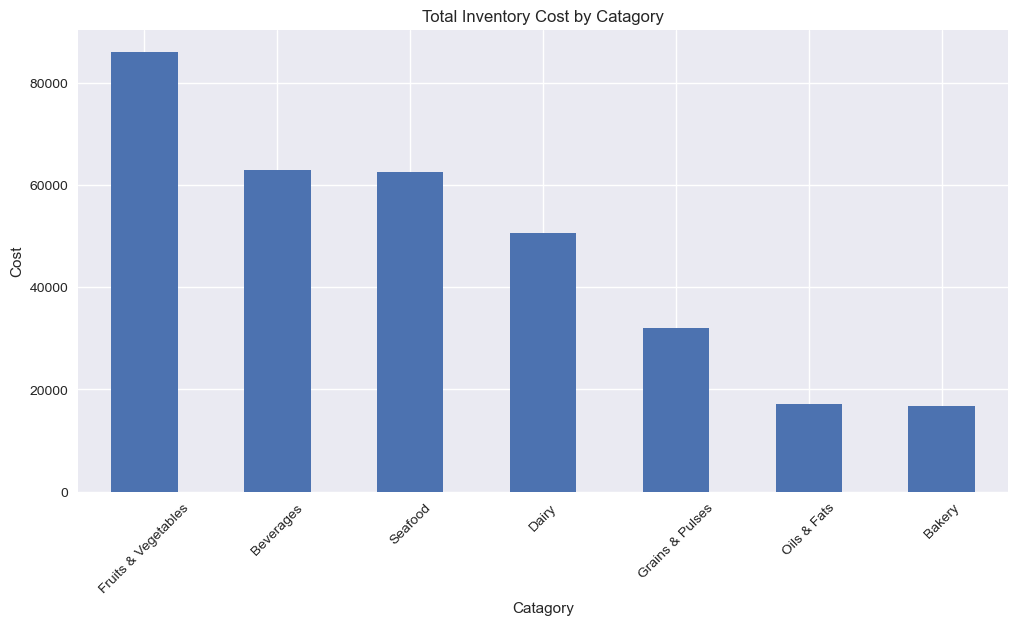

In [24]:
# ==================================================
# Cost by Catagory
# ==================================================

import matplotlib.pyplot as plt

# Create total inventory cost
data["Total_Inventory_Cost"] = (
    data["Stock_Quantity"] * data["Unit_Price"]
)

# Group by catagory
category_cost = (
    data.groupby("Catagory")["Total_Inventory_Cost"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,6))

category_cost.plot(kind="bar")

plt.title("Total Inventory Cost by Catagory")

plt.xlabel("Catagory")

plt.ylabel("Cost")

plt.xticks(rotation=45)

plt.show()

<Figure size 1200x600 with 0 Axes>

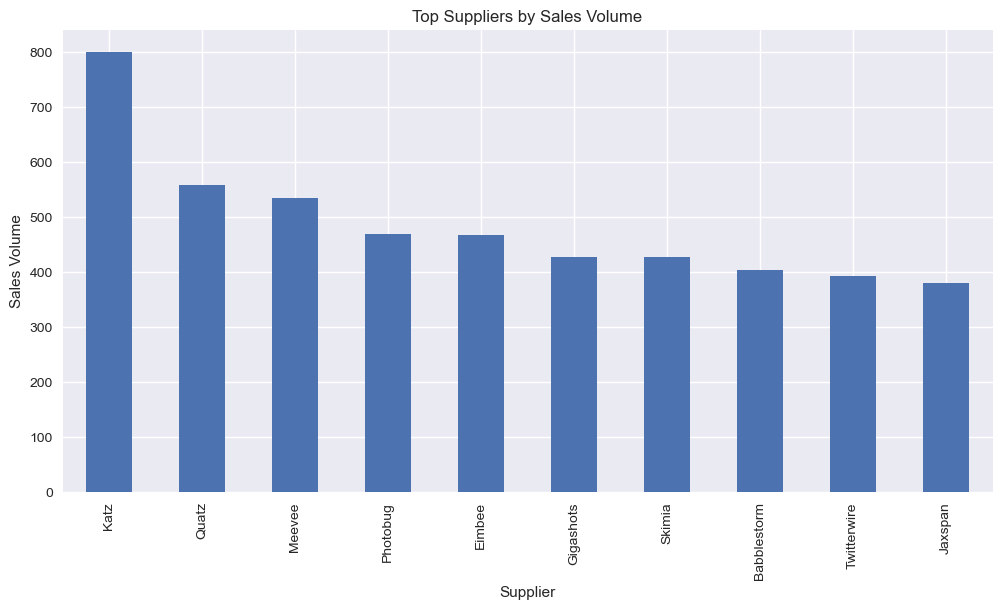

In [14]:
# ==================================================
# Top Suppliers by Sales
# ==================================================

plt.figure(figsize=(12,6))

supplier_sales = (
    data.groupby("Supplier_Name")["Sales_Volume"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

supplier_sales.plot(kind="bar")

plt.title("Top Suppliers by Sales Volume")

plt.xlabel("Supplier")

plt.ylabel("Sales Volume")

plt.show()

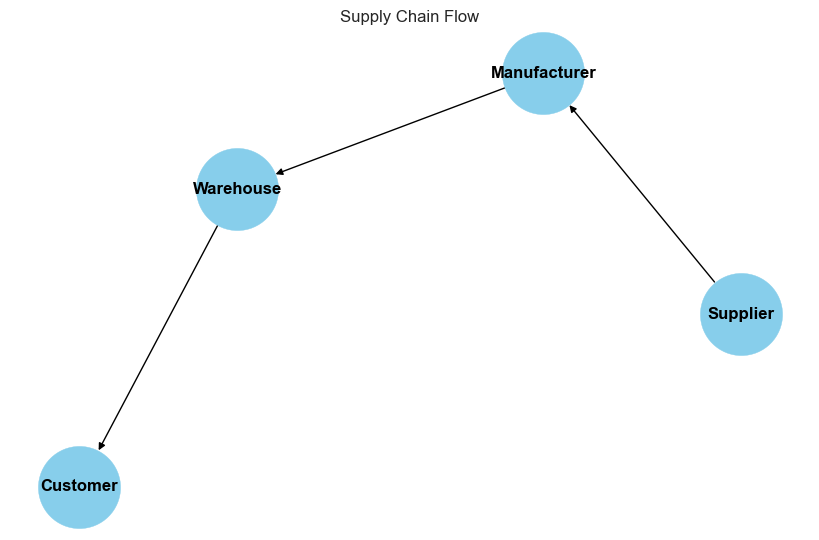

In [15]:
# ==================================================
# Supply Chain Flow Diagram
# ==================================================

import networkx as nx

G = nx.DiGraph()

G.add_edges_from([
    ("Supplier", "Manufacturer"),
    ("Manufacturer", "Warehouse"),
    ("Warehouse", "Customer")
])

plt.figure(figsize=(8,5))

nx.draw(
    G,
    with_labels=True,
    node_color="skyblue",
    node_size=3500,
    font_size=12,
    font_weight="bold",
    arrows=True
)

plt.title("Supply Chain Flow")

plt.show()

In [16]:
# ==================================================
# Faster Delivery Scenario
# ==================================================

data["Improved_Delivery_Time"] = (
    data["Delivery_Time"] * 0.8
)

In [17]:
# ==================================================
# Cost Reduction Scenario
# ==================================================

data["Reduced_Cost"] = (
    data["Total_Inventory_Cost"] * 0.9
)

In [18]:
# ==================================================
# Inventory Optimization
# ==================================================

data["Optimized_Inventory"] = (
    data["Stock_Quantity"] * 0.85
)

In [19]:
# ==================================================
# KPI Comparison
# ==================================================

comparison = pd.DataFrame({

    "Metric": [
        "Inventory Cost",
        "Delivery Time",
        "Inventory Level"
    ],

    "Before": [
        data["Total_Inventory_Cost"].mean(),
        data["Delivery_Time"].mean(),
        data["Stock_Quantity"].mean()
    ],

    "After": [
        data["Reduced_Cost"].mean(),
        data["Improved_Delivery_Time"].mean(),
        data["Optimized_Inventory"].mean()
    ]
})

comparison

,Metric,Before,After
0,Inventory Cost,336.014859,302.413373
1,Delivery Time,-2.710101,-2.168081
2,Inventory Level,55.609091,47.267727
